In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
pd.set_option("display.width", 120)

In [5]:
n_buildings = 6
building_ids = [f"BLD-{i:02d}" for i in range(1, n_buildings + 1)]
n_records = 320
dates = pd.date_range("2025-01-01", periods=400, freq="h")

rows = []
for _ in range(n_records):
    bld = np.random.choice(building_ids)
    dt = np.random.choice(dates)
    hour = pd.Timestamp(dt).hour

    occupancy = max(0, int(np.random.normal(40, 20) * (1 if 7 <= hour <= 19 else 0.2)))
    temperature = np.random.normal(28, 4)
    humidity = np.clip(np.random.normal(60, 10), 20, 95)
    ac_hours = np.clip(np.random.normal(6, 2.5) * (1 if temperature > 26 else 0.4), 0, 24)
    lighting_hours = np.clip(np.random.normal(8, 2) * (1 if 6 <= hour <= 20 else 0.3), 0, 24)
    equipment_load = np.clip(np.random.normal(15, 6) * (1 if occupancy > 5 else 0.3), 0, 60)
    renewable = np.clip(np.random.normal(5, 2), 0, 15)

    total_energy = (20 + 0.35 * occupancy + 1.8 * ac_hours + 1.1 * lighting_hours
                     + 0.6 * equipment_load + 0.4 * max(temperature - 24, 0)
                     - 0.8 * renewable + np.random.normal(0, 4))
    total_energy = max(total_energy, 5)

    rows.append([bld, dt, occupancy, round(temperature, 1), round(humidity, 1),
                 round(ac_hours, 2), round(lighting_hours, 2), round(equipment_load, 2),
                 round(renewable, 2), round(total_energy, 2)])

df = pd.DataFrame(rows, columns=["Building_ID", "DateTime", "Occupancy", "Temperature", "Humidity",
                                  "AC_Hours", "Lighting_Hours", "Equipment_Load",
                                  "Renewable_Energy_kWh", "Total_Energy_kWh"])

miss_idx = np.random.choice(df.index, 18, replace=False)
for i in miss_idx:
    col = np.random.choice(["Temperature", "Humidity", "Equipment_Load"])
    df.loc[i, col] = np.nan

dup_rows = df.sample(12, random_state=1)
df_raw = pd.concat([df, dup_rows], ignore_index=True)
df_raw.to_csv("energy_raw.csv", index=False)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (332, 10)


,Building_ID,DateTime,Occupancy,Temperature,Humidity,AC_Hours,Lighting_Hours,Equipment_Load,Renewable_Energy_kWh,Total_Energy_kWh
0,BLD-04,2025-01-15 12:00:00,50,25.5,48.0,4.54,7.81,9.43,3.23,56.31
1,BLD-03,2025-01-07 05:00:00,8,27.4,60.2,4.93,2.08,14.30,5.44,36.46
2,BLD-04,2025-01-03 06:00:00,7,29.4,64.2,8.08,7.41,14.82,5.19,54.72
3,BLD-02,2025-01-12 00:00:00,11,23.6,71.3,2.77,2.17,8.05,6.13,28.33
4,BLD-06,2025-01-17 05:00:00,9,22.4,38.2,1.36,2.50,16.95,6.49,25.97


In [6]:
print("Missing values per column:\n", df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())

df_clean = df_raw.drop_duplicates().copy()
for col in ["Temperature", "Humidity", "Equipment_Load"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean = df_clean.reset_index(drop=True)

print("\nAfter cleaning -> shape:", df_clean.shape, "| missing values:", df_clean.isna().sum().sum())
df_clean.to_csv("energy_cleaned.csv", index=False)

Missing values per column:
 Building_ID             0
DateTime                0
Occupancy               0
Temperature             4
Humidity                7
AC_Hours                0
Lighting_Hours          0
Equipment_Load          8
Renewable_Energy_kWh    0
Total_Energy_kWh        0
dtype: int64

Duplicate rows: 12

After cleaning -> shape: (320, 10) | missing values: 0


In [7]:
high_ac = df_clean[df_clean["AC_Hours"] > 8]
print("Records with AC_Hours > 8:", len(high_ac))
print(df_clean.loc[0:4, ["Building_ID", "Occupancy", "Total_Energy_kWh"]])

print("\nDescriptive statistics:\n", df_clean.describe().round(2))

Records with AC_Hours > 8: 56
  Building_ID  Occupancy  Total_Energy_kWh
0      BLD-04         50             56.31
1      BLD-03          8             36.46
2      BLD-04          7             54.72
3      BLD-02         11             28.33
4      BLD-06          9             25.97

Descriptive statistics:
                             DateTime  Occupancy  Temperature  Humidity  AC_Hours  Lighting_Hours  Equipment_Load  \
count                            320     320.00       320.00    320.00    320.00          320.00          320.00   
mean   2025-01-08 23:06:56.249999872      23.46        28.03     59.65      5.03            6.07           13.29   
min              2025-01-01 01:00:00       0.00        17.70     25.20      0.00            0.68            0.00   
25%              2025-01-04 20:45:00       7.00        25.20     52.68      2.55            2.60            8.29   
50%              2025-01-08 16:30:00      13.00        27.75     60.50      4.61            6.54          

In [8]:
summary = (df_clean.groupby("Building_ID")["Total_Energy_kWh"]
           .agg(mean_kWh="mean", max_kWh="max", records="count")
           .sort_values("mean_kWh", ascending=False))
print(summary)

              mean_kWh  max_kWh  records
Building_ID                             
BLD-06       50.380909    78.50       66
BLD-03       49.939200    75.71       50
BLD-04       49.867447    90.42       47
BLD-01       49.571569    78.56       51
BLD-05       49.360377    75.88       53
BLD-02       47.613396    77.36       53


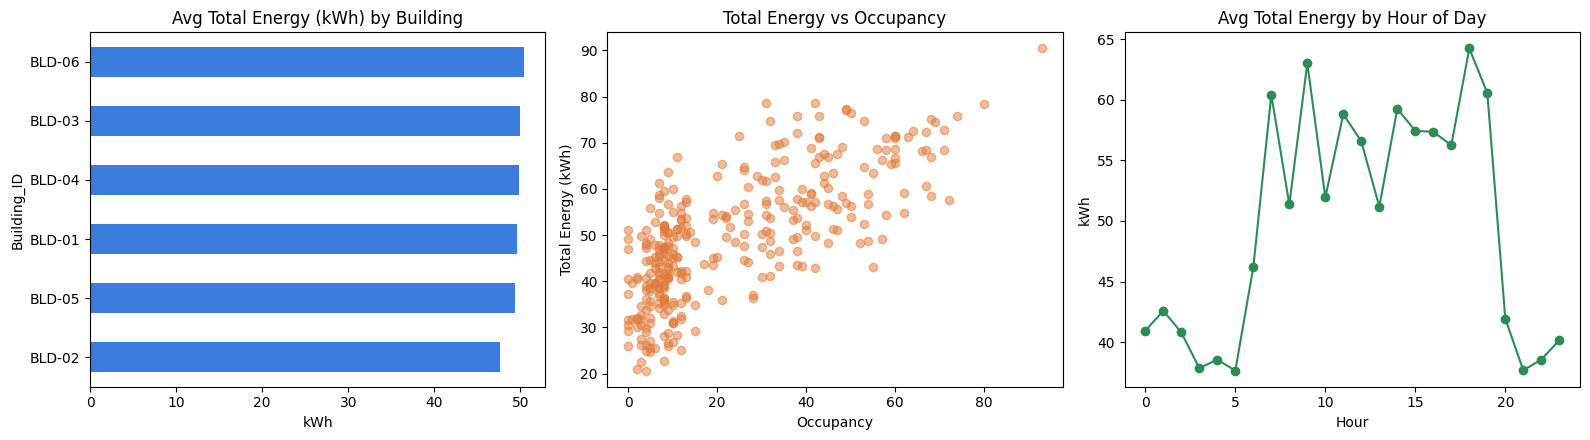

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

summary["mean_kWh"].sort_values().plot(kind="barh", ax=axes[0], color="#3b7ddd")
axes[0].set_title("Avg Total Energy (kWh) by Building")
axes[0].set_xlabel("kWh")

axes[1].scatter(df_clean["Occupancy"], df_clean["Total_Energy_kWh"], alpha=0.5, color="#e07b39")
axes[1].set_title("Total Energy vs Occupancy")
axes[1].set_xlabel("Occupancy"); axes[1].set_ylabel("Total Energy (kWh)")

df_clean["Hour"] = pd.to_datetime(df_clean["DateTime"]).dt.hour
by_hour = df_clean.groupby("Hour")["Total_Energy_kWh"].mean()
axes[2].plot(by_hour.index, by_hour.values, marker="o", color="#2e8b57")
axes[2].set_title("Avg Total Energy by Hour of Day")
axes[2].set_xlabel("Hour"); axes[2].set_ylabel("kWh")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=120)
plt.show()

In [10]:
features = ["Occupancy", "Temperature", "Humidity", "AC_Hours",
            "Lighting_Hours", "Equipment_Load", "Renewable_Energy_kWh"]
target = "Total_Energy_kWh"

X = df_clean[features].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

def evaluate(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "R2": r2_score(y_true, y_pred)}

knn_results = {}
for k in [3, 5, 7, 9]:
    model = KNeighborsRegressor(n_neighbors=k).fit(X_train_s, y_train)
    knn_results[k] = evaluate(y_test, model.predict(X_test_s))

knn_table = pd.DataFrame(knn_results).T
print(knn_table.round(3))

best_k = knn_table["RMSE"].idxmin()
print(f"\nSelected K = {best_k} (lowest validation RMSE)")

knn_best = KNeighborsRegressor(n_neighbors=best_k).fit(X_train_s, y_train)
pred_knn = knn_best.predict(X_test_s)

     MAE   RMSE     R2
3  4.766  6.458  0.787
5  4.619  6.060  0.813
7  4.624  5.965  0.819
9  4.496  5.759  0.831

Selected K = 9 (lowest validation RMSE)


In [11]:
def lwr_predict(X_train, y_train, X_query, tau=1.5, ridge=1e-6):
    Xb = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    preds = []
    for xq in X_query:
        xqb = np.hstack([1.0, xq])
        w = np.exp(-np.sum((X_train - xq) ** 2, axis=1) / (2 * tau ** 2))
        W = np.diag(w)
        A = Xb.T @ W @ Xb + ridge * np.eye(Xb.shape[1])
        b = Xb.T @ W @ y_train
        theta = np.linalg.solve(A, b)
        preds.append(xqb @ theta)
    return np.array(preds)

pred_lwr = lwr_predict(X_train_s, y_train, X_test_s, tau=1.5)
res_lwr = evaluate(y_test, pred_lwr)
print("LWR (tau=1.5):", {k: round(v, 3) for k, v in res_lwr.items()})

for tau in [0.5, 1.0, 1.5, 3.0, 6.0]:
    p = lwr_predict(X_train_s, y_train, X_test_s, tau=tau)
    r = evaluate(y_test, p)
    print(f"  tau={tau:>4}: RMSE={r['RMSE']:.3f}, R2={r['R2']:.3f}")

LWR (tau=1.5): {'MAE': 3.494, 'RMSE': 4.232, 'R2': 0.909}
  tau= 0.5: RMSE=8.979, R2=0.589
  tau= 1.0: RMSE=4.722, R2=0.886
  tau= 1.5: RMSE=4.232, R2=0.909
  tau= 3.0: RMSE=4.056, R2=0.916
  tau= 6.0: RMSE=4.055, R2=0.916


In [12]:
rbf_model = KernelRidge(kernel="rbf", alpha=0.01, gamma=0.01).fit(X_train_s, y_train)
pred_rbf = rbf_model.predict(X_test_s)
res_rbf = evaluate(y_test, pred_rbf)
print("RBF (gamma=0.01, alpha=0.01):", {k: round(v, 3) for k, v in res_rbf.items()})

for gamma in [0.005, 0.01, 0.05, 0.1, 0.2]:
    p = KernelRidge(kernel="rbf", alpha=0.01, gamma=gamma).fit(X_train_s, y_train).predict(X_test_s)
    r = evaluate(y_test, p)
    print(f"  gamma={gamma:>5}: RMSE={r['RMSE']:.3f}, R2={r['R2']:.3f}")

RBF (gamma=0.01, alpha=0.01): {'MAE': 3.434, 'RMSE': 4.285, 'R2': 0.906}
  gamma=0.005: RMSE=4.181, R2=0.911
  gamma= 0.01: RMSE=4.285, R2=0.906
  gamma= 0.05: RMSE=5.798, R2=0.829
  gamma=  0.1: RMSE=7.957, R2=0.677
  gamma=  0.2: RMSE=11.326, R2=0.346


In [13]:
def recommend(query_row, neighbor_rows):
    avg_ac = neighbor_rows["AC_Hours"].mean()
    avg_light = neighbor_rows["Lighting_Hours"].mean()
    avg_renew = neighbor_rows["Renewable_Energy_kWh"].mean()
    tips = []
    if query_row["AC_Hours"] > avg_ac * 1.1:
        tips.append("AC hours are above similar historical cases — consider raising setpoint or scheduling.")
    if query_row["Lighting_Hours"] > avg_light * 1.1:
        tips.append("Lighting hours exceed similar cases — check for after-hours/unoccupied lighting.")
    if query_row["Renewable_Energy_kWh"] < avg_renew * 0.9:
        tips.append("Renewable offset is below similar cases — verify on-site generation is online.")
    return tips if tips else ["Usage is in line with similar historical cases; no immediate action flagged."]

rng = np.random.default_rng(7)
sample_idx = rng.choice(len(X_test_s), 5, replace=False)
train_df = pd.DataFrame(X_train, columns=features)
train_df["Total_Energy_kWh"] = y_train

for i in sample_idx:
    xq = X_test_s[i]
    dists = np.linalg.norm(X_train_s - xq, axis=1)
    nn_idx = np.argsort(dists)[:3]
    neighbors = train_df.iloc[nn_idx]
    query_row = pd.Series(X_test[i], index=features)

    print(f"\nQuery case  -> actual Total_Energy_kWh = {y_test[i]:.1f}")
    for rank, j in enumerate(nn_idx, 1):
        print(f"  match {rank}: distance={dists[j]:.3f}, actual={y_train[j]:.1f} kWh, "
              f"AC_Hours={X_train[j][features.index('AC_Hours')]:.1f}, "
              f"Lighting_Hours={X_train[j][features.index('Lighting_Hours')]:.1f}")
    for tip in recommend(query_row, neighbors):
        print("   ->", tip)


Query case  -> actual Total_Energy_kWh = 50.9
  match 1: distance=1.198, actual=43.9 kWh, AC_Hours=5.7, Lighting_Hours=2.6
  match 2: distance=1.480, actual=40.6 kWh, AC_Hours=3.5, Lighting_Hours=3.0
  match 3: distance=1.645, actual=45.5 kWh, AC_Hours=5.5, Lighting_Hours=2.3
   -> AC hours are above similar historical cases — consider raising setpoint or scheduling.
   -> Renewable offset is below similar cases — verify on-site generation is online.

Query case  -> actual Total_Energy_kWh = 47.1
  match 1: distance=0.892, actual=48.0 kWh, AC_Hours=7.2, Lighting_Hours=2.2
  match 2: distance=0.893, actual=45.2 kWh, AC_Hours=6.8, Lighting_Hours=2.7
  match 3: distance=0.994, actual=47.5 kWh, AC_Hours=4.3, Lighting_Hours=3.4
   -> Usage is in line with similar historical cases; no immediate action flagged.

Query case  -> actual Total_Energy_kWh = 43.2
  match 1: distance=1.264, actual=55.7 kWh, AC_Hours=2.1, Lighting_Hours=8.2
  match 2: distance=1.600, actual=60.1 kWh, AC_Hours=2.2, L

In [14]:
comparison = pd.DataFrame({
    f"KNN (K={best_k})": knn_results[best_k],
    "LWR (tau=1.5)": res_lwr,
    "RBF (gamma=0.01)": res_rbf,
}).T.round(3)
print(comparison)

best_model_name = comparison["RMSE"].idxmin()
print(f"\nBest model by RMSE: {best_model_name}")

preds_map = {f"KNN (K={best_k})": pred_knn, "LWR (tau=1.5)": pred_lwr, "RBF (gamma=0.01)": pred_rbf}
best_pred = preds_map[best_model_name]
errors = np.abs(y_test - best_pred)
high_err_idx = np.argsort(errors)[-2:]

print(f"\nHigh-error cases for {best_model_name}:")
for i in high_err_idx:
    feats = dict(zip(features, X_test[i]))
    print(f"  actual={y_test[i]:.1f}, predicted={best_pred[i]:.1f}, |error|={errors[i]:.1f}")
    print(f"    features: {feats}")

                    MAE   RMSE     R2
KNN (K=9)         4.496  5.759  0.831
LWR (tau=1.5)     3.494  4.232  0.909
RBF (gamma=0.01)  3.434  4.285  0.906

Best model by RMSE: LWR (tau=1.5)

High-error cases for LWR (tau=1.5):
  actual=43.2, predicted=52.9, |error|=9.7
    features: {'Occupancy': np.float64(55.0), 'Temperature': np.float64(26.7), 'Humidity': np.float64(58.7), 'AC_Hours': np.float64(0.0), 'Lighting_Hours': np.float64(9.83), 'Equipment_Load': np.float64(10.84), 'Renewable_Energy_kWh': np.float64(5.66)}
  actual=59.9, predicted=48.5, |error|=11.4
    features: {'Occupancy': np.float64(10.0), 'Temperature': np.float64(32.6), 'Humidity': np.float64(63.4), 'AC_Hours': np.float64(4.96), 'Lighting_Hours': np.float64(9.27), 'Equipment_Load': np.float64(12.885000000000002), 'Renewable_Energy_kWh': np.float64(5.36)}
